In [ ]:
# Identify sketched 1904 farm drainage issues

In [4]:
#!/usr/bin/env python3
"""
Pattern-match "Diagram-like" landscapes in Union County using a drainage class raster
-------------------------------------------------------------------------------

Core idea:
  Use soil drainage class (raster) as a wetness proxy. Compute fraction of each
  3x3-mile window that is classified as 'somewhat poorly', 'poorly', or 'very poorly' drained.

Optional add-ons:
  - Streams diagonality (requires NHD flowlines or similar)
  - Slope flatness (requires a DEM)

Outputs:
  - outputs_union_drainclass/ranked_windows.csv
  - outputs_union_drainclass/top_windows.gpkg
  - outputs_union_drainclass/quicklooks/ (optional)

User-provided path:
  DrainClass_UTM15N.tif

"""

from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union

warnings.filterwarnings("ignore", category=UserWarning)

# For VAT reading (DBF)
from dbfread import DBF

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.windows import from_bounds

# -----------------------------
# SETTINGS
# -----------------------------

M_PER_MILE = 1609.344

@dataclass
class Settings:
    # Your drainage class raster (UTM15N)
    drain_tif: Path = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "DML_2025/data/external/DrainageClass_GIS/DrainClass_UTM15N.tif"

    # Output
    out_dir: Path = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "DML_2025/outputs/union_diagram_patternmatch_drainclass"

    # Analysis CRS (match your DML project)
    crs_proj: str = "EPSG:5070"

    # Window params
    window_miles: float = 3.0
    stride_miles: float = 0.5

    top_n: int = 25
    make_quicklooks: bool = False  # set True later if you want PNGs

    # Wet class keywords to search in the VAT labels (case-insensitive substring)
    wet_keywords: tuple[str, ...] = (
        "very poorly",
        "poorly",
        "somewhat poorly",
    )

    # If VAT auto-detection fails, set values manually here after inspection:
    wet_values_manual = {5, 6, 7}

S = Settings()

# -----------------------------
# County boundary (TIGER download)
# -----------------------------

def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)


from pathlib import Path
import geopandas as gpd
import os

COUNTY_SHP = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "cb_2018_us_county_500k/cb_2018_us_county_500k.shp"

def get_union_county_polygon_local(crs_proj: str = "EPSG:5070") -> gpd.GeoDataFrame:
    """
    Read Union County, Iowa from a local Census county shapefile.

    Your file: cb_2018_us_county_500k.shp
    Fields typically include:
      - STATEFP (Iowa = '19')
      - NAME (county name, e.g., 'Union')
      - COUNTYFP, GEOID, etc.
    """
    if not COUNTY_SHP.exists():
        raise FileNotFoundError(f"County shapefile not found: {COUNTY_SHP}")

    counties = gpd.read_file(COUNTY_SHP)

    # Filter to Iowa + Union County
    # (CB files use strings for STATEFP)
    union = counties[(counties["STATEFP"] == "19") & (counties["NAME"].str.lower() == "union")].copy()

    if union.empty:
        # Helpful debug if fields differ
        raise ValueError(
            "Could not find Union County, IA in the county shapefile. "
            f"Available columns: {list(counties.columns)}"
        )

    union = union.to_crs(crs_proj)
    union["county_name"] = "Union"
    return union[["county_name", "geometry"]]


def get_county_polygon(county_name: str, state_fips: str = "19") -> gpd.GeoDataFrame:
    tiger_dir = S.out_dir / "tiger"
    counties = download_tiger_county_boundary(state_fips, tiger_dir)
    county = counties[counties["NAME"].str.lower() == county_name.lower()]
    if county.empty:
        raise ValueError(f"Could not find county NAME='{county_name}' in TIGER data.")
    county = county.to_crs(S.crs_proj)
    county["county_name"] = county_name
    return county[["county_name", "geometry"]]


# -----------------------------
# Window grid
# -----------------------------

def generate_windows(county_geom, window_size_m: float, stride_m: float) -> gpd.GeoDataFrame:
    minx, miny, maxx, maxy = county_geom.bounds
    xs = np.arange(minx, maxx, stride_m)
    ys = np.arange(miny, maxy, stride_m)

    geoms = []
    for x in xs:
        for y in ys:
            w = box(x, y, x + window_size_m, y + window_size_m)
            if w.intersects(county_geom):
                geoms.append(w)

    wins = gpd.GeoDataFrame({"win_id": np.arange(len(geoms), dtype=int)}, geometry=geoms, crs=S.crs_proj)
    # keep windows with >=10% overlap
    inter_area = wins.geometry.intersection(county_geom).area
    wins = wins.loc[inter_area > 0.10 * (window_size_m * window_size_m)].copy()
    wins.reset_index(drop=True, inplace=True)
    return wins


# -----------------------------
# Drainage raster + VAT
# -----------------------------

def find_vat_dbf(tif_path: Path) -> Path:
    """Given DrainClass_UTM15N.tif, look for the companion .tif.vat.dbf."""
    vat = tif_path.with_suffix(tif_path.suffix + ".vat.dbf")  # .tif.vat.dbf
    if vat.exists():
        return vat
    # sometimes named differently; try glob
    candidates = list(tif_path.parent.glob(tif_path.name + ".vat.dbf"))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(f"Could not find VAT DBF next to {tif_path}")


def read_vat(vat_dbf: Path) -> pd.DataFrame:
    df = pd.DataFrame(iter(DBF(str(vat_dbf))))
    # Normalize colnames
    df.columns = [c.strip() for c in df.columns]
    return df


def detect_value_and_label_columns(vat: pd.DataFrame) -> tuple[str, str]:
    """
    Try to detect a value column and a label column in a VAT table.
    Common patterns:
      value: VALUE, Value, GRIDCODE
      label: CLASS, LABEL, DESCRIPTION, DRAINCLASS, NAME
    """
    cols = {c.lower(): c for c in vat.columns}

    value_candidates = ["value", "gridcode", "code", "classvalue"]
    label_candidates = ["label", "class", "name", "description", "drain", "drainclass", "drclass"]

    value_col = None
    for k in value_candidates:
        if k in cols:
            value_col = cols[k]
            break
    if value_col is None:
        # fallback: first integer column
        for c in vat.columns:
            if pd.api.types.is_integer_dtype(vat[c]) or pd.api.types.is_numeric_dtype(vat[c]):
                value_col = c
                break

    label_col = None
    for k in label_candidates:
        for c in vat.columns:
            if k in c.lower():
                label_col = c
                break
        if label_col is not None:
            break
    if label_col is None:
        # fallback: first object column
        for c in vat.columns:
            if pd.api.types.is_object_dtype(vat[c]):
                label_col = c
                break

    if value_col is None or label_col is None:
        raise ValueError(f"Could not detect VALUE/LABEL columns in VAT. Columns={list(vat.columns)}")

    return value_col, label_col


def infer_wet_values_from_vat(vat: pd.DataFrame, wet_keywords: tuple[str, ...]) -> set[int]:
    value_col, label_col = detect_value_and_label_columns(vat)
    vals = []
    for _, r in vat.iterrows():
        label = str(r[label_col]).strip().lower()
        if any(k in label for k in wet_keywords):
            vals.append(int(r[value_col]))
    return set(vals)


def reproject_raster_to_5070(in_tif: Path, out_tif: Path, dst_crs: str) -> None:
    if out_tif.exists():
        return

    with rasterio.open(in_tif) as src:
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        profile = src.profile.copy()
        profile.update(crs=dst_crs, transform=transform, width=width, height=height)

        out_tif.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(out_tif, "w", **profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest,  # preserve classes
            )


def wet_fraction_in_window(src: rasterio.io.DatasetReader, geom, wet_values: set[int]) -> float:
    win = from_bounds(*geom.bounds, transform=src.transform)
    arr = src.read(1, window=win, masked=True)
    if arr.mask.all():
        return 0.0
    a = arr.compressed()
    if a.size == 0:
        return 0.0
    return float(np.isin(a, list(wet_values)).mean())


# -----------------------------
# Scoring utils
# -----------------------------

def normalize_series(x: pd.Series) -> pd.Series:
    xmin, xmax = x.min(), x.max()
    if np.isclose(xmin, xmax):
        return pd.Series(np.zeros(len(x)), index=x.index, dtype=float)
    return (x - xmin) / (xmax - xmin)


# -----------------------------
# Main
# -----------------------------

def main():
    ensure_dir(S.out_dir)

    # County boundary
    county = get_union_county_polygon_local(crs_proj=S.crs_proj)

    county_geom = unary_union(county.geometry)
    print("[county] Union County boundary loaded.")

    # Windows
    win_size_m = S.window_miles * M_PER_MILE
    stride_m = S.stride_miles * M_PER_MILE
    wins = generate_windows(county_geom, win_size_m, stride_m)
    print(f"[windows] {len(wins):,} candidate windows.")

    # Drainage raster + VAT
    drain_tif = S.drain_tif
    if not drain_tif.exists():
        raise FileNotFoundError(f"Drainage raster not found: {drain_tif}")

    vat_dbf = find_vat_dbf(drain_tif)
    vat = read_vat(vat_dbf)

    # Infer wet values from VAT unless user specifies manually
    if S.wet_values_manual is not None:
        wet_values = set(S.wet_values_manual)
        print(f"[wet] using manual wet values: {sorted(wet_values)}")
    else:
        wet_values = infer_wet_values_from_vat(vat, S.wet_keywords)
        print(f"[wet] inferred wet values from VAT: {sorted(wet_values)}")
        if len(wet_values) == 0:
            print("[wet] WARNING: Could not infer wet classes from VAT labels.")
            print("      Open the VAT table and set wet_values_manual in Settings.")

    # Reproject drainage raster to EPSG:5070
    drain_5070 = S.out_dir / "DrainClass_epsg5070.tif"
    reproject_raster_to_5070(drain_tif, drain_5070, S.crs_proj)
    print(f"[drain] ready (5070): {drain_5070}")

    # Compute wet fraction per window
    rows = []
    with rasterio.open(drain_5070) as src:
        for _, r in wins.iterrows():
            frac = wet_fraction_in_window(src, r.geometry, wet_values) if len(wet_values) > 0 else 0.0
            rows.append(dict(win_id=int(r.win_id), wet_frac=frac))

    df = pd.DataFrame(rows)
    df["wet_component"] = normalize_series(df["wet_frac"])
    df["score"] = df["wet_component"]  # currently wetness-only ranking

    df.sort_values("score", ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Export CSV
    csv_path = S.out_dir / "ranked_windows.csv"
    df.to_csv(csv_path, index=False)
    print(f"[export] {csv_path}")

    # Export top windows
    top_ids = df.head(S.top_n)["win_id"].to_numpy()
    top_wins = wins[wins["win_id"].isin(top_ids)].merge(df, on="win_id", how="left")
    gpkg_path = S.out_dir / "top_windows.gpkg"
    top_wins.to_file(gpkg_path, layer="top_windows", driver="GPKG")
    print(f"[export] {gpkg_path}")

    print("\nTop 10 windows by wetness fraction:")
    print(df.head(10).to_string(index=False))


if __name__ == "__main__":
    main()


[county] Union County boundary loaded.
[windows] 1,703 candidate windows.
[wet] using manual wet values: [5, 6, 7]
[drain] ready (5070): /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/outputs/union_diagram_patternmatch_drainclass/DrainClass_epsg5070.tif
[export] /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/outputs/union_diagram_patternmatch_drainclass/ranked_windows.csv
[export] /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/outputs/union_diagram_patternmatch_drainclass/top_windows.gpkg

Top 10 windows by wetness fraction:
 win_id  wet_frac  wet_component    score
    129  0.780098       1.000000 1.000000
    131  0.776563       0.990597 0.990597
    128  0.775653       0.988176 0.988176
    230  0.772542       0.979900 0.97990

In [1]:
# make template from sketch



'/opt/anaconda3/envs/dml_wetlands_env/bin/python'

In [1]:
#!/usr/bin/env python3
from pathlib import Path
import numpy as np
import cv2
from skimage.morphology import remove_small_objects
import matplotlib.pyplot as plt
import os

# ------------------
# USER SETTINGS
# ------------------
SKETCH_PNG = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "DML_2025/data/external/Historical Drainage/diagram_1_field.png"   # <-- set to your sketch image file
N = 128                                    # output grid size
MIN_OBJ = 80                               # remove tiny specks (tune)
STREAM_THICKNESS_PCT = 85                  # percentile for "thick ink" threshold (tune)

OUT_DIR = Path("./sketch_template")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------
# LOAD + PREPROCESS
# ------------------
img = cv2.imread(str(SKETCH_PNG), cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Could not read {SKETCH_PNG}")

# 1) Normalize contrast
img_blur = cv2.GaussianBlur(img, (5,5), 0)

# 2) Binarize: ink vs background (adaptive works well for uneven scans)
bin_img = cv2.adaptiveThreshold(
    img_blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    blockSize=51, C=10
)
# bin_img: 255 where ink; 0 background
ink = (bin_img > 0)

# 3) Clean: remove isolated specks
ink_clean = remove_small_objects(ink, min_size=MIN_OBJ)

# ------------------
# SPLIT INTO STREAM-LIKE LINES vs WET SHADING BLOBS (heuristic)
# ------------------
# Idea: use distance transform to estimate "stroke thickness".
# Thick strokes (creek lines) will have larger distance-to-edge.
ink_u8 = (ink_clean.astype(np.uint8) * 255)
dist = cv2.distanceTransform(ink_u8, distanceType=cv2.DIST_L2, maskSize=3)

# Threshold thickness: keep top X percentile as "thick ink" = candidate stream network
thr = np.percentile(dist[dist > 0], STREAM_THICKNESS_PCT) if np.any(dist > 0) else 0
stream_candidate = (dist >= thr)

# Wetness candidate = ink that is NOT thick strokes
wet_candidate = ink_clean & (~stream_candidate)

# Optional: clean wet blobs further (remove thin line remnants)
wet_candidate = remove_small_objects(wet_candidate, min_size=MIN_OBJ)

# ------------------
# RESAMPLE TO N x N TEMPLATE GRIDS
# ------------------
def to_N(mask_bool, N):
    m = mask_bool.astype(np.uint8) * 255
    mN = cv2.resize(m, (N, N), interpolation=cv2.INTER_NEAREST)
    return (mN > 0).astype(np.uint8)

T_stream = to_N(stream_candidate, N)
T_wet = to_N(wet_candidate, N)

np.save(OUT_DIR / "template_stream.npy", T_stream)
np.save(OUT_DIR / "template_wet.npy", T_wet)

# ------------------
# QUICKLOOKS
# ------------------
fig, ax = plt.subplots(1, 4, figsize=(14, 4))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(ink_clean, cmap="gray"); ax[1].set_title("Ink mask"); ax[1].axis("off")
ax[2].imshow(T_stream, cmap="gray"); ax[2].set_title("Template stream"); ax[2].axis("off")
ax[3].imshow(T_wet, cmap="gray"); ax[3].set_title("Template wet"); ax[3].axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR / "template_quicklook.png", dpi=200)
plt.close()

print("Wrote:")
print(" -", OUT_DIR / "template_stream.npy")
print(" -", OUT_DIR / "template_wet.npy")
print(" -", OUT_DIR / "template_quicklook.png")
print("\nTune STREAM_THICKNESS_PCT and MIN_OBJ until stream/wet separation looks right.")


/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_83338/4010752647.py:40: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  ink_clean = remove_small_objects(ink, min_size=MIN_OBJ)
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_83338/4010752647.py:58: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  

Wrote:
 - sketch_template/template_stream.npy
 - sketch_template/template_wet.npy
 - sketch_template/template_quicklook.png

Tune STREAM_THICKNESS_PCT and MIN_OBJ until stream/wet separation looks right.


In [ ]:
# displya the 4-panel fig

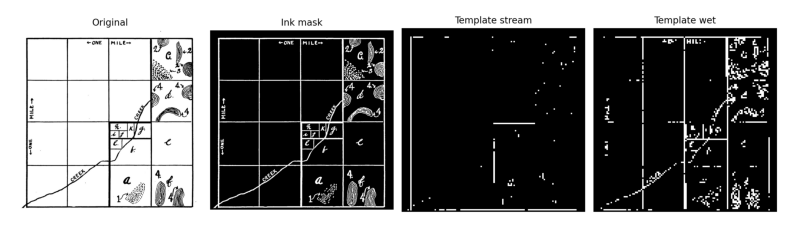

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("sketch_template/template_quicklook.png")

plt.figure(figsize=(10, 3))
plt.imshow(img)
plt.axis("off")
plt.show()


In [ ]:
# new attempt

In [16]:
#!/usr/bin/env python3
"""
Identify candidate 1x1-mile landscapes in Union County that resemble the structure in Diagram 1:
  - diagonal-ish stream crossing
  - patchy wet-prone soils (drainage class 5-7)
  - mixed wet/dry (avoid uniform wetness)

Outputs:
  - ranked_windows.csv
  - top_windows.gpkg

Author: drop-in script for DML_2025 workflow
"""

from __future__ import annotations
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union, linemerge

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.windows import from_bounds

from skimage.measure import label, regionprops

warnings.filterwarnings("ignore", category=UserWarning)

M_PER_MILE = 1609.344

# -----------------------------
# SETTINGS
# -----------------------------

class S:
    COUNTY_SHP = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "cb_2018_us_county_500k/cb_2018_us_county_500k.shp"

    DRAIN_TIF = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "DML_2025/data/external/DrainageClass_GIS/DrainClass_UTM15N.tif"

    # ✅ set this to your shapefile
    NHD_FLOWLINES = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "NHD/NHDPlusMS/NHDPlus07/NHDSnapshot/Hydrography/NHDFlowline.shp"

    OUT_DIR = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "DML_2025/outputs/union_sketch_candidates_1mi"

    CRS_PROJ = "EPSG:5070"

    WINDOW_MILES = 1.0
    STRIDE_MILES = 0.25
    TOP_N = 50

    WET_VALUES = {5, 6, 7}

    TARGET_WET_FRAC = 0.35
    WET_FRAC_TOL = 0.30

    MIN_PATCH_PIX = 12

    MIN_STREAM_LEN_FRAC_DIAG = 0.40
    DIAGONAL_ANGLE_TARGET_DEG = 45.0
    DIAGONAL_ANGLE_TOL_DEG = 25.0



# -----------------------------
# UTILITIES
# -----------------------------
def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)

def normalize_01(x: pd.Series) -> pd.Series:
    xmin, xmax = float(x.min()), float(x.max())
    if np.isclose(xmin, xmax):
        return pd.Series(np.zeros(len(x)), index=x.index, dtype=float)
    return (x - xmin) / (xmax - xmin)

def gaussian_pref(x: float, mu: float, sigma: float) -> float:
    """Preference score peaked at mu; sigma controls width. Returns 0..1."""
    return float(math.exp(-0.5 * ((x - mu) / sigma) ** 2))

def axial_angle_mean_deg(angles_rad: np.ndarray) -> float:
    """
    Mean orientation for axial data (lines): angle and angle+pi are equivalent.
    Returns degrees in [0, 180).
    """
    if angles_rad.size == 0:
        return np.nan
    # double-angle trick
    x = np.cos(2 * angles_rad).mean()
    y = np.sin(2 * angles_rad).mean()
    mean2 = math.atan2(y, x) / 2.0
    deg = (math.degrees(mean2) + 180.0) % 180.0
    return deg

def axial_concentration(angles_rad: np.ndarray) -> float:
    """0..1 measure of how concentrated the orientations are (1=very aligned)."""
    if angles_rad.size == 0:
        return 0.0
    x = np.cos(2 * angles_rad).mean()
    y = np.sin(2 * angles_rad).mean()
    return float(math.hypot(x, y))


# -----------------------------
# DATA LOADERS
# -----------------------------
def get_union_county_polygon_local(crs_proj: str) -> gpd.GeoDataFrame:
    counties = gpd.read_file(S.COUNTY_SHP)
    # Union County, Iowa GEOID = 19175 (stable)
    union = counties[counties["GEOID"] == "19175"].copy()
    if union.empty:
        raise ValueError("Union County (GEOID=19175) not found in county shapefile.")
    union = union.to_crs(crs_proj)
    union["county_name"] = "Union"
    return union[["county_name", "geometry"]]

def reproject_raster(in_tif: Path, out_tif: Path, dst_crs: str) -> None:
    if out_tif.exists():
        return
    with rasterio.open(in_tif) as src:
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        profile = src.profile.copy()
        profile.update(crs=dst_crs, transform=transform, width=width, height=height)
        out_tif.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(out_tif, "w", **profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest,
            )

def load_flowlines(county_geom) -> gpd.GeoDataFrame:
    if S.NHD_FLOWLINES is None:
        raise RuntimeError("S.NHD_FLOWLINES is None. Set it to NHDFlowline.shp")

    p = Path(S.NHD_FLOWLINES)
    if not p.exists():
        raise FileNotFoundError(f"NHD flowlines not found: {p}")

    fl = gpd.read_file(p)
    fl = fl.to_crs(S.CRS_PROJ)
    fl = fl[fl.intersects(county_geom)].copy()

    # keep only line geometries (defensive)
    fl = fl[fl.geometry.type.isin(["LineString", "MultiLineString"])].copy()
    return fl

# -----------------------------
# WINDOW GRID
# -----------------------------
def generate_windows(county_geom, window_m: float, stride_m: float) -> gpd.GeoDataFrame:
    minx, miny, maxx, maxy = county_geom.bounds
    xs = np.arange(minx, maxx, stride_m)
    ys = np.arange(miny, maxy, stride_m)

    geoms = []
    for x in xs:
        for y in ys:
            w = box(x, y, x + window_m, y + window_m)
            if w.intersects(county_geom):
                # keep if at least 30% overlaps county
                if w.intersection(county_geom).area >= 0.30 * (window_m * window_m):
                    geoms.append(w)

    wins = gpd.GeoDataFrame({"win_id": np.arange(len(geoms), dtype=int)}, geometry=geoms, crs=S.CRS_PROJ)
    return wins


# -----------------------------
# METRICS
# -----------------------------
def wet_metrics_for_window(src_drain, geom, wet_values: set[int], min_patch_pix: int):
    """Return wet fraction + patch metrics from drainage raster in this window."""
    win = from_bounds(*geom.bounds, transform=src_drain.transform)
    arr = src_drain.read(1, window=win, masked=True)

    if arr.mask.all():
        return dict(wet_frac=0.0, n_patches=0, largest_patch_frac=0.0, mean_patch_frac=0.0)

    a = arr.filled(0)
    wet = np.isin(a, list(wet_values)) & (~arr.mask)

    wet_frac = float(wet.mean()) if wet.size else 0.0

    # Connected components on wet mask (4-neighbor)
    lbl = label(wet.astype(np.uint8), connectivity=1)
    props = regionprops(lbl)

    # Filter tiny patches
    areas = np.array([p.area for p in props], dtype=float)
    areas = areas[areas >= min_patch_pix]

    n_patches = int(len(areas))
    if n_patches == 0:
        return dict(wet_frac=wet_frac, n_patches=0, largest_patch_frac=0.0, mean_patch_frac=0.0)

    total_pix = float(wet.size)
    largest_patch_frac = float(areas.max() / total_pix)
    mean_patch_frac = float(areas.mean() / total_pix)

    return dict(
        wet_frac=wet_frac,
        n_patches=n_patches,
        largest_patch_frac=largest_patch_frac,
        mean_patch_frac=mean_patch_frac,
    )

from shapely.geometry import LineString, MultiLineString

def force_2d(geom):
    """Return a 2D version of a (Multi)LineString by dropping Z/M dimensions."""
    if geom is None or geom.is_empty:
        return geom
    gt = geom.geom_type
    if gt == "LineString":
        return LineString([(c[0], c[1]) for c in geom.coords])
    if gt == "MultiLineString":
        return MultiLineString([LineString([(c[0], c[1]) for c in ls.coords]) for ls in geom.geoms])
    return geom


from shapely.geometry import LineString, MultiLineString
import os

def force_2d(geom):
    """Drop Z/M dimensions from (Multi)LineString; return geom unchanged for other types."""
    if geom is None or geom.is_empty:
        return geom
    gt = geom.geom_type
    if gt == "LineString":
        return LineString([(c[0], c[1]) for c in geom.coords])
    if gt == "MultiLineString":
        return MultiLineString([LineString([(c[0], c[1]) for c in ls.coords]) for ls in geom.geoms])
    return geom


def stream_metrics_for_window(flowlines: gpd.GeoDataFrame, geom):
    """
    Stable stream metrics per window. Always returns a dict.
    n_parts is a simple proxy = number of clipped line features in the window.
    """
    # default (no stream)
    out = dict(stream_len_m=0.0, dom_angle_deg=np.nan, angle_conc=0.0, n_parts=0)

    sub = flowlines[flowlines.intersects(geom)].copy()
    if sub.empty:
        return out

    # Clip and drop empties
    sub["geometry"] = sub.geometry.intersection(geom)
    sub = sub[~sub.is_empty].copy()
    if sub.empty:
        return out

    # Force 2D to avoid shapely Z issues
    sub["geometry"] = sub["geometry"].apply(force_2d)
    sub = sub[~sub.is_empty].copy()
    if sub.empty:
        return out

    # Length
    out["stream_len_m"] = float(sub.length.sum())

    # Complexity proxy
    out["n_parts"] = int(len(sub))

    # Orientation: accumulate segment angles
    angles = []
    for g in sub.geometry:
        if g.geom_type == "LineString":
            coords = list(g.coords)
            for c0, c1 in zip(coords[:-1], coords[1:]):
                x0, y0 = c0[0], c0[1]
                x1, y1 = c1[0], c1[1]
                dx, dy = (x1 - x0), (y1 - y0)
                if dx == 0 and dy == 0:
                    continue
                ang = math.atan2(dy, dx)
                ang = (ang + math.pi) % math.pi  # axial
                angles.append(ang)

        elif g.geom_type == "MultiLineString":
            for ls in g.geoms:
                coords = list(ls.coords)
                for c0, c1 in zip(coords[:-1], coords[1:]):
                    x0, y0 = c0[0], c0[1]
                    x1, y1 = c1[0], c1[1]
                    dx, dy = (x1 - x0), (y1 - y0)
                    if dx == 0 and dy == 0:
                        continue
                    ang = math.atan2(dy, dx)
                    ang = (ang + math.pi) % math.pi
                    angles.append(ang)

    angles = np.array(angles, dtype=float)
    if angles.size:
        out["dom_angle_deg"] = axial_angle_mean_deg(angles)
        out["angle_conc"] = axial_concentration(angles)

    return out


# -----------------------------
# SKETCH-LIKE SCORE
# -----------------------------
def sketch_score(row, window_diag_m: float) -> float:
    """
    Combine metrics into a 0..1-ish score:
      - stream crossing & diagonal orientation
      - mixed wetness (not uniform)
      - patchy wetness (multiple patches, not one slab)
      - prefer a single main stream part
    """

    # --- Stream presence / crossing ---
    stream_len_frac = row["stream_len_m"] / window_diag_m if window_diag_m > 0 else 0.0
    stream_present = 1.0 if stream_len_frac >= S.MIN_STREAM_LEN_FRAC_DIAG else 0.0

    # --- Diagonal preference (axial): treat 45 and 135 as equivalent ---
    # Compute distance to nearest diagonal target in degrees (mod 180)
    if np.isnan(row["dom_angle_deg"]):
        diag_pref = 0.0
    else:
        ang = row["dom_angle_deg"] % 180.0
        d1 = abs(ang - 45.0)
        d2 = abs(ang - 135.0)
        d = min(d1, d2)
        # Convert to preference: 1 at 0°, decays with tolerance
        diag_pref = gaussian_pref(d, mu=0.0, sigma=S.DIAGONAL_ANGLE_TOL_DEG / 2)

    # Encourage aligned segments (one dominant orientation)
    align_pref = float(row["angle_conc"])  # 0..1

    # Prefer fewer merged parts (proxy for “one main crossing”)
    parts_penalty = 1.0 / (1.0 + max(0, row["n_parts"] - 1))

    # --- Wetness preference: mixed wet/dry ---
    wet_pref = gaussian_pref(row["wet_frac"], mu=S.TARGET_WET_FRAC, sigma=S.WET_FRAC_TOL / 2)

    # --- Patchiness preference: multiple wet patches, but not one huge patch ---
    # This is a soft preference; you can tune after first run.
    patch_pref = 1.0 - math.exp(-row["n_patches"] / 3.0)  # rises with n_patches, saturates
    huge_patch_penalty = 1.0 - min(0.9, row["largest_patch_frac"] * 2.0)  # penalize very large single patch

    # Combine (weights reflect sketch emphasis)
    score = (
        0.30 * stream_present +
        0.20 * diag_pref +
        0.10 * align_pref +
        0.10 * parts_penalty +
        0.20 * wet_pref +
        0.10 * patch_pref
    ) * huge_patch_penalty

    return float(score)


# -----------------------------
# MAIN
# -----------------------------
def main():
    ensure_dir(S.OUT_DIR)

    # County
    county = get_union_county_polygon_local(crs_proj=S.CRS_PROJ)
    county_geom = unary_union(county.geometry)
    print("[county] Union County loaded.")

    # Windows (1x1 mile)
    window_m = S.WINDOW_MILES * M_PER_MILE
    stride_m = S.STRIDE_MILES * M_PER_MILE
    wins = generate_windows(county_geom, window_m, stride_m)
    print(f"[windows] {len(wins):,} candidate 1x1-mile windows.")

    # Drainage raster reprojected to 5070
    if not S.DRAIN_TIF.exists():
        raise FileNotFoundError(f"Drainage raster not found: {S.DRAIN_TIF}")

    drain_5070 = S.OUT_DIR / "DrainClass_epsg5070.tif"
    reproject_raster(S.DRAIN_TIF, drain_5070, S.CRS_PROJ)
    print(f"[drain] ready: {drain_5070}")

    # Flowlines
    flow = load_flowlines(county_geom)
    print(f"[flowlines] loaded: {len(flow):,} features intersecting county bbox.")

    # Per-window metrics
    rows = []
    window_diag_m = math.sqrt(2) * window_m

    with rasterio.open(drain_5070) as src_drain:
        for _, w in wins.iterrows():
            geom = w.geometry

            wm = wet_metrics_for_window(src_drain, geom, S.WET_VALUES, S.MIN_PATCH_PIX)
            sm = stream_metrics_for_window(flow, geom)

            rec = dict(win_id=int(w.win_id))
            rec.update(wm)
            rec.update(sm)
            rows.append(rec)

    df = pd.DataFrame(rows)

    # Score
    df["sketch_score"] = df.apply(lambda r: sketch_score(r, window_diag_m), axis=1)

    # Sort + export
    df.sort_values("sketch_score", ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)

    csv_path = S.OUT_DIR / "ranked_windows.csv"
    df.to_csv(csv_path, index=False)
    print(f"[export] {csv_path}")

    top_ids = df.head(S.TOP_N)["win_id"].to_numpy()
    top_wins = wins[wins["win_id"].isin(top_ids)].merge(df, on="win_id", how="left")

    gpkg_path = S.OUT_DIR / "top_windows.gpkg"
    top_wins.to_file(gpkg_path, layer="top_windows", driver="GPKG")
    print(f"[export] {gpkg_path}")

    print("\nTop 10 sketch-like windows:")
    print(df.head(10)[
        ["win_id","sketch_score","wet_frac","n_patches","largest_patch_frac","stream_len_m","dom_angle_deg","n_parts","angle_conc"]
    ].to_string(index=False))


if __name__ == "__main__":
    main()


[county] Union County loaded.
[windows] 6,778 candidate 1x1-mile windows.
[drain] ready: /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/outputs/union_sketch_candidates_1mi/DrainClass_epsg5070.tif
[flowlines] loaded: 15 features intersecting county bbox.
[export] /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/outputs/union_sketch_candidates_1mi/ranked_windows.csv
[export] /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/outputs/union_sketch_candidates_1mi/top_windows.gpkg

Top 10 sketch-like windows:
 win_id  sketch_score  wet_frac  n_patches  largest_patch_frac  stream_len_m  dom_angle_deg  n_parts  angle_conc
   5875      0.635485  0.446048         21            0.099340   2171.710299      56.121643        3    0.622505
   6311   

In [10]:
from pathlib import Path
import os

base = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "DML_2025/data/external/NHDPlus"

print("Base exists:", base.exists(), base)

matches = list(base.rglob("NHDFlowline.shp"))
print("Matches found:", len(matches))
for m in matches[:20]:
    print(m)


Base exists: False /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/data/external/NHDPlus
Matches found: 0
